# Predicting Building Energy Efficiency

Estimating the **heating load** and **cooling load** of residential buildings from their shape and glazing characteristics.

**Dataset:** UCI Energy Efficiency dataset (`ENB2012_data.csv`), 768 simulated buildings with 8 design features and 2 target variables.
**Models:** Multi-output Linear Regression (baseline) and Random Forest Regressor.
**Tools:** Python, pandas, NumPy, Matplotlib, seaborn, scikit-learn.

## Table of Contents
1. [Project Overview](#1.-Project-Overview)
2. [Data Loading](#2.-Data-Loading)
3. [Data Preparation](#3.-Data-Preparation)
4. [Data Quality and Summary Statistics](#4.-Data-Quality-and-Summary-Statistics)
5. [Exploratory Data Analysis](#5.-Exploratory-Data-Analysis)
6. [Train/Test Split](#6.-Train/Test-Split)
7. [Modeling](#7.-Modeling)
8. [Feature Importance](#8.-Feature-Importance)
9. [Predicted vs Actual](#9.-Predicted-vs-Actual)
10. [Key Findings](#10.-Key-Findings)
11. [Limitations and Next Steps](#11.-Limitations-and-Next-Steps)

## 1. Project Overview

Heating and cooling account for a large share of the energy a building uses, and much of that demand is decided at the design stage. If the load can be estimated from basic geometry, designers can compare options before anything is built.

**Objective:** predict two continuous targets at once, `heating_load` and `cooling_load`, from eight building characteristics.

**Approach:**
1. Load and clean the data
2. Check data quality
3. Explore relationships between features and targets
4. Train a linear regression baseline
5. Train a random forest and compare it against the baseline
6. Inspect feature importance and prediction quality

**Feature description**

| Original name | Column used here | Meaning |
|---|---|---|
| X1 | `relative_compactness` | Compactness of the building shape |
| X2 | `surface_area` | Total surface area (m²) |
| X3 | `wall_area` | Wall area (m²) |
| X4 | `roof_area` | Roof area (m²) |
| X5 | `overall_height` | Building height (m) |
| X6 | `orientation` | Direction the building faces (2 to 5) |
| X7 | `glazing_area` | Glazing area as a fraction of floor area |
| X8 | `glazing_area_distribution` | How glazing is spread across facades (0 to 5) |
| Y1 | `heating_load` | Target: heating load |
| Y2 | `cooling_load` | Target: cooling load |

## 2. Data Loading

In [1]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/Shanmukhi1920/Energy-Efficiency-Prediction/main/data/ENB2012_data.csv')

In [2]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


The raw file uses generic column names (`X1` to `X8`, `Y1`, `Y2`), which are hard to read in plots and model output. They are renamed in the next section.

## 3. Data Preparation

Renaming the columns to descriptive names so that every later table and chart is self-explanatory.

In [3]:
df.columns = ['relative_compactness', 'surface_area', 'wall_area', 'roof_area',
              'overall_height', 'orientation', 'glazing_area',
              'glazing_area_distribution', 'heating_load', 'cooling_load']

In [4]:
df.head()

,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_distribution,heating_load,cooling_load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


## 4. Data Quality and Summary Statistics

Before modeling, I check for missing values, data types, duplicate rows, and the range of each variable.

### 4.1 Missing values

In [5]:
df.isnull().sum()

relative_compactness         0
surface_area                 0
wall_area                    0
roof_area                    0
overall_height               0
orientation                  0
glazing_area                 0
glazing_area_distribution    0
heating_load                 0
cooling_load                 0
dtype: int64

### 4.2 Data types and structure

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   relative_compactness       768 non-null    float64
 1   surface_area               768 non-null    float64
 2   wall_area                  768 non-null    float64
 3   roof_area                  768 non-null    float64
 4   overall_height             768 non-null    float64
 5   orientation                768 non-null    int64  
 6   glazing_area               768 non-null    float64
 7   glazing_area_distribution  768 non-null    int64  
 8   heating_load               768 non-null    float64
 9   cooling_load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [7]:
df.shape

(768, 10)

### 4.3 Summary statistics

In [8]:
df.describe()

,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_distribution,heating_load,cooling_load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


### 4.4 Duplicate rows

In [9]:
df.duplicated().sum()

np.int64(0)

### 4.5 Discrete features

In [10]:
df['glazing_area'].value_counts()


glazing_area
0.10    240
0.25    240
0.40    240
0.00     48
Name: count, dtype: int64

In [11]:
df['glazing_area_distribution'].value_counts()

glazing_area_distribution
1    144
2    144
3    144
4    144
5    144
0     48
Name: count, dtype: int64

**Observations**
- The dataset has 768 rows and 10 columns, with no missing values and no duplicate rows, so no imputation or row removal was needed.
- All columns are numeric.
- `glazing_area` takes only four values (0, 0.10, 0.25, 0.40) and `glazing_area_distribution` only six (0 to 5). Both behave like categorical settings even though they are stored as numbers.
- Buildings with no glazing (48 rows) have distribution 0, which is the only case where that value appears.

## 5. Exploratory Data Analysis

### 5.1 Correlation matrix

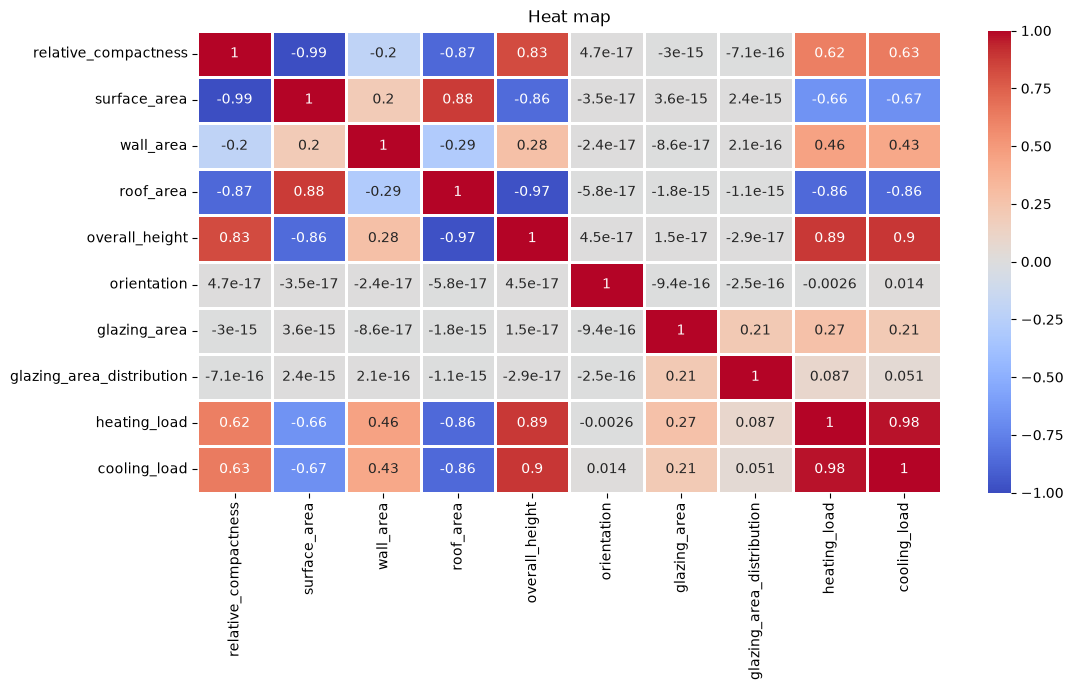

In [12]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
corr_matrix=df.corr()
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',vmin=-1,vmax=1,linewidth=1)
plt.title('Heat map')
plt.show()

**Observations**
- `overall_height` has the strongest positive correlation with both targets (about 0.89 for heating and 0.90 for cooling).
- `roof_area` and `surface_area` are negatively correlated with both targets (about -0.86 and -0.66 respectively).
- `relative_compactness` is positively correlated with both loads (about 0.62 and 0.63).
- `orientation` has essentially no linear relationship with either target, and `glazing_area_distribution` has only a very weak one.
- The two targets are almost perfectly correlated with each other (about 0.98).
- Several predictors are strongly correlated with one another. For example, `relative_compactness` and `surface_area` sit at about -0.99. This multicollinearity matters when interpreting linear coefficients and feature importances later.

### 5.2 Feature distributions

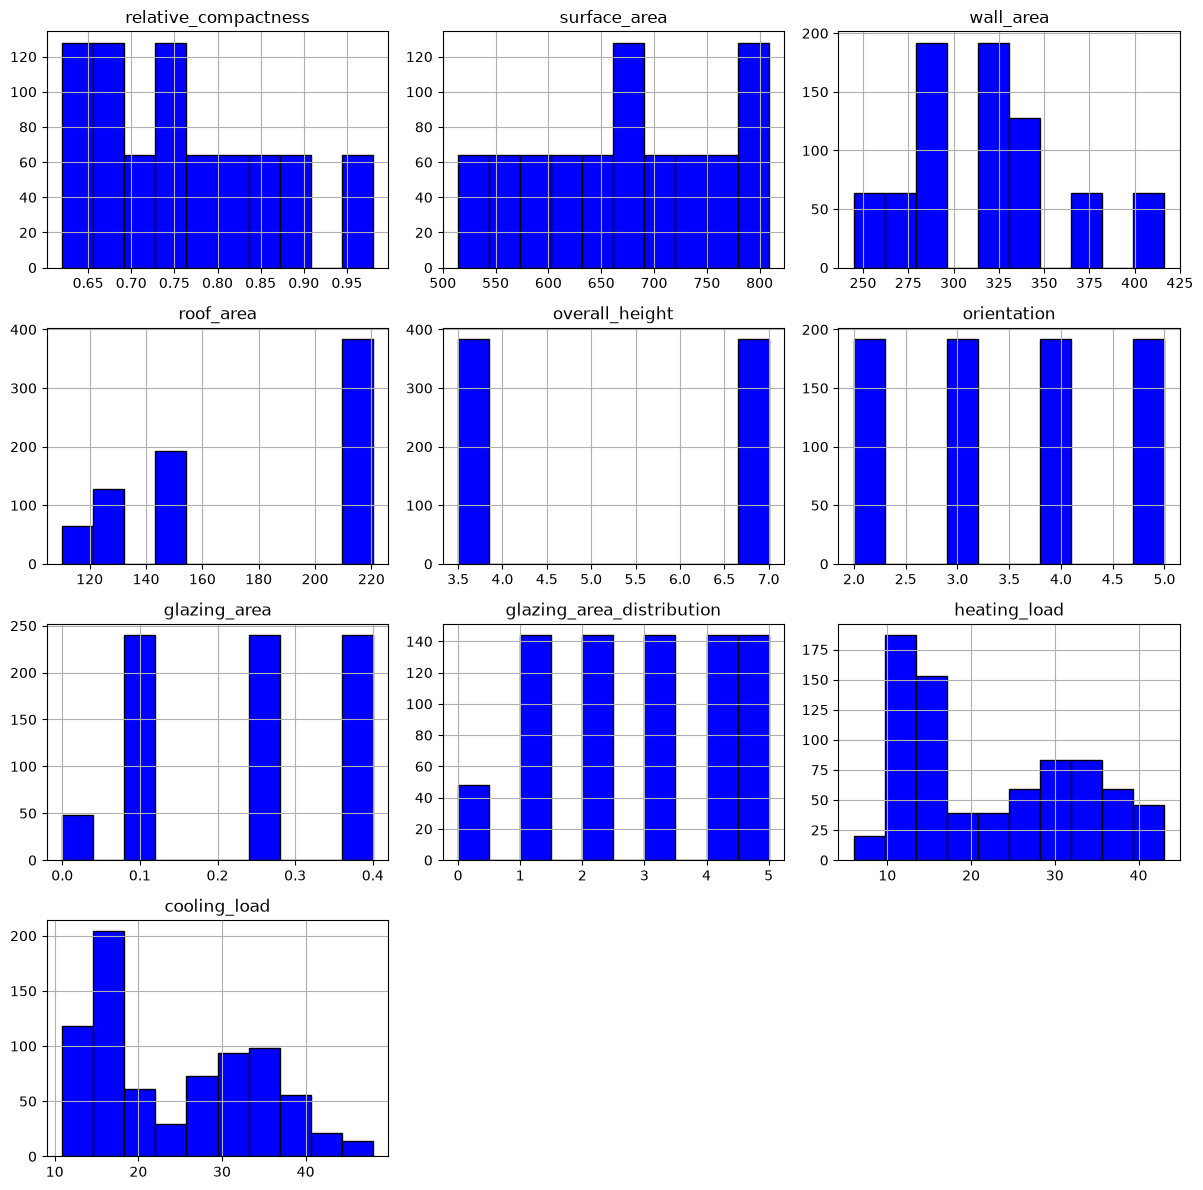

In [13]:

    
df.hist(figsize=(12,12),color='blue',edgecolor='black');

plt.subplots_adjust(hspace=1,wspace=1)
plt.tight_layout()
plt.show()

Most features take a small set of discrete values, which is expected for a dataset built from a fixed set of simulated building configurations. There are no outliers to treat.

### 5.3 Features vs heating load

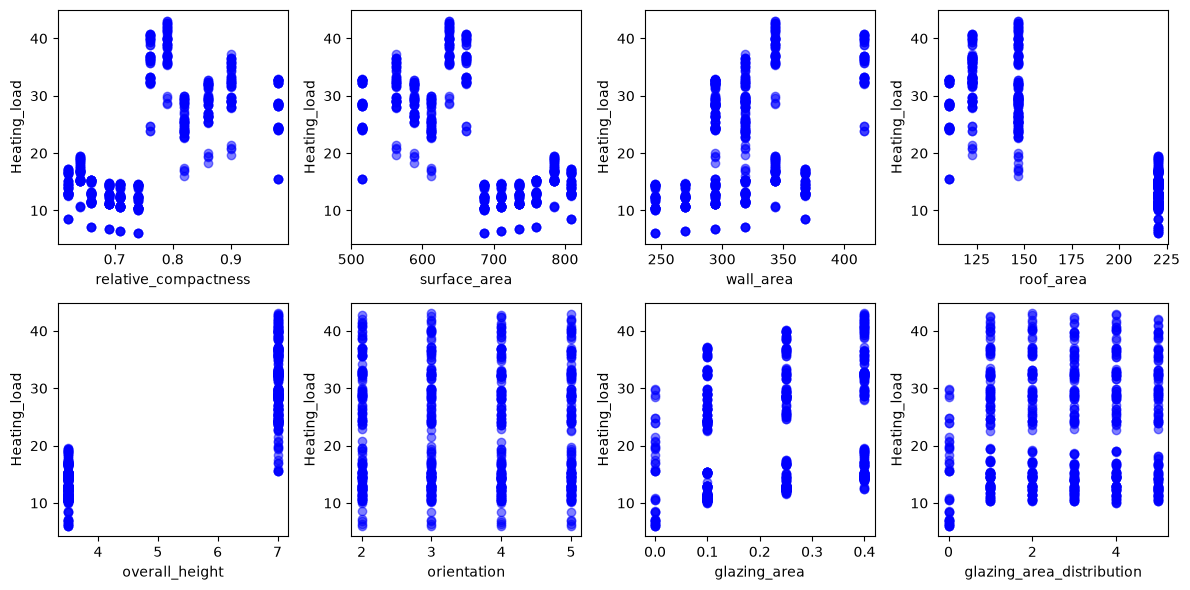

In [14]:
features=df[df.columns.drop(['heating_load','cooling_load'])]
target1=df['heating_load']

fig,axes=plt.subplots(2,4,figsize=(12,6))
axes=axes.flatten()

for idx,col in enumerate(features.columns):
    axes[idx].scatter(features[col],target1,color='Blue',alpha=0.5)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Heating_load')
    plt.tight_layout()

### 5.4 Features vs cooling load

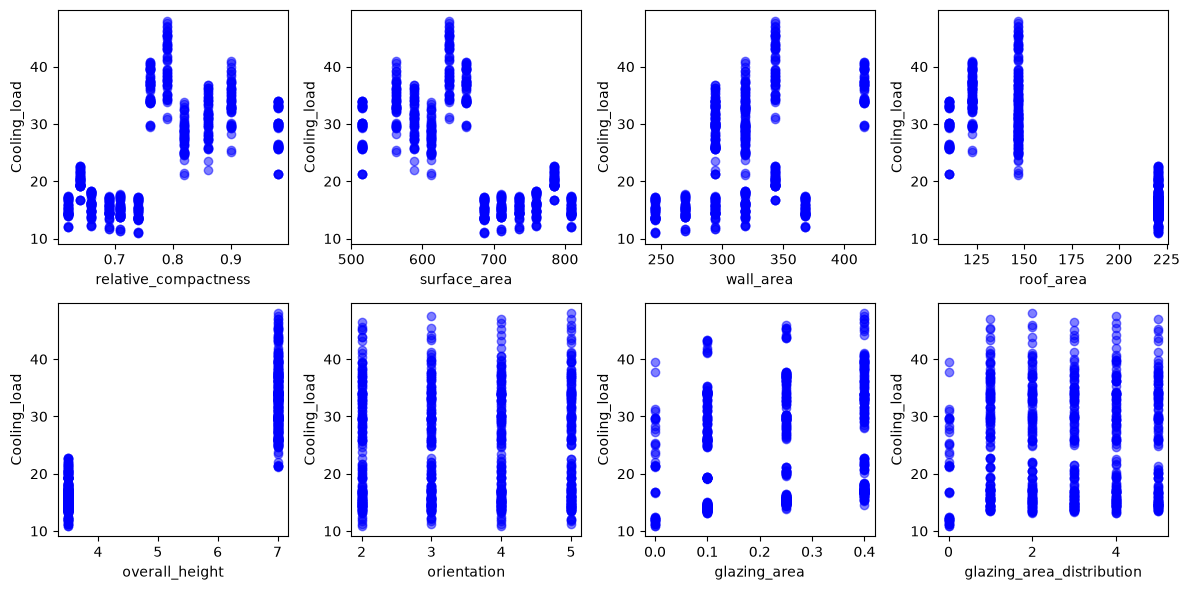

In [15]:
target2=df['cooling_load']
fig,axes=plt.subplots(2,4,figsize=(12,6))
axes=axes.flatten()

for idx,col in enumerate(features.columns):
    axes[idx].scatter(features[col],target2,color='Blue',alpha=0.5)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Cooling_load')
    plt.tight_layout()

The scatter plots agree with the correlation matrix. Height, roof area and compactness show clear structure against both loads, while orientation shows none.

### 5.5 Target distributions

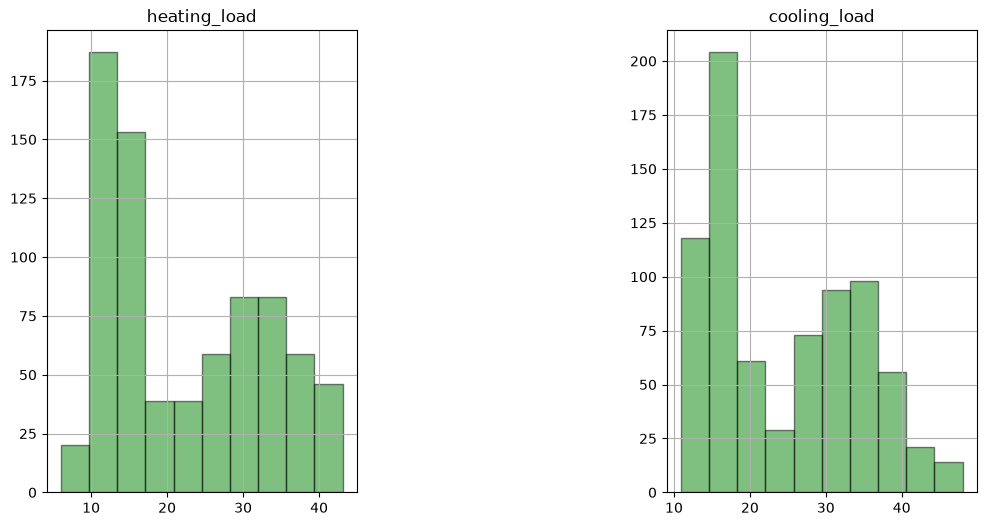

In [16]:

    
df[['heating_load','cooling_load']].hist(figsize=(12,6),color='green',edgecolor='black',alpha=0.5);

plt.subplots_adjust(hspace=1,wspace=1)
plt.show()

Both targets are spread across a wide range and are only mildly right-skewed (skewness of roughly 0.36 for heating and 0.40 for cooling), so no target transformation was applied.

## 6. Train/Test Split

The two targets are modeled together. Features are separated from the targets, and 20% of the data is held out for testing (`random_state=42` for reproducibility).

In [17]:
from sklearn.model_selection import train_test_split
X=df[df.columns.drop(['heating_load','cooling_load'])]
y=df[['heating_load','cooling_load']]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [18]:
X_train.shape

(614, 8)

In [19]:
X_test.shape

(154, 8)

The split gives 614 training rows and 154 test rows.

## 7. Modeling

Both models predict `heating_load` and `cooling_load` at the same time. I evaluate with MAE, MSE, RMSE and R², and compare train R² with test R² to check for overfitting.

### 7.1 Baseline: Linear Regression

A linear model is a natural starting point. It is fast, easy to interpret, and shows how much of the signal is captured by simple linear relationships.

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import numpy as np
import pandas as pd


lin_reg=LinearRegression()
lin_reg.fit(X_train,y_train)
y_pred=lin_reg.predict(X_test)

coef=pd.DataFrame(lin_reg.coef_.T,index=X_test.columns,columns=y_test.columns)
print(coef)
print(f'intercept : {lin_reg.intercept_}')
print('------TEST SCORES------')
for i, target in enumerate(y_test):
    mae=mean_absolute_error(y_test[target],y_pred[:,i])
    mse=mean_squared_error(y_test[target],y_pred[:,i])
    r2=r2_score(y_test[target],y_pred[:,i])
    rmse=np.sqrt(mse)
    print(f'\n{target}\nMAE : {mae:.3f}\nMSE : {mse:.3f}\nR2 : {r2:.3f}\nRMSE : {rmse:.3f}\n')

                           heating_load  cooling_load
relative_compactness         -61.873354    -71.084528
surface_area                  -0.060105     -0.069220
wall_area                      0.037553      0.025423
roof_area                     -0.048829     -0.047322
overall_height                 4.123669      4.046160
orientation                   -0.032439      0.055210
glazing_area                  20.143192     14.787587
glazing_area_distribution      0.211103      0.033740
intercept : [ 79.72697958 100.59454263]
------TEST SCORES------

heating_load
MAE : 2.182
MSE : 9.153
R2 : 0.912
RMSE : 3.025


cooling_load
MAE : 2.195
MSE : 9.893
R2 : 0.893
RMSE : 3.145



In [21]:
print("---- TRAIN vs TEST R2 ----")
train_pred = lin_reg.predict(X_train)
for i, target in enumerate(y_train.columns):
    print(target, 'Train R2:', round(r2_score(y_train[target], train_pred[:, i]), 3),
          '| Test R2:', round(r2_score(y_test[target], y_pred[:, i]), 3))

---- TRAIN vs TEST R2 ----
heating_load Train R2: 0.917 | Test R2: 0.912
cooling_load Train R2: 0.886 | Test R2: 0.893


**Observations**
- The linear model explains about 91% of the variance in heating load and about 89% in cooling load on unseen data.
- Train and test R² are close to each other, so the model is not overfitting. Its limitation is bias, not variance.
- The coefficients show that taller buildings and larger glazing area increase both loads, while higher relative compactness lowers them. The compactness coefficient is large mainly because the feature only ranges from about 0.62 to 0.98, and it is inflated further by its high correlation with surface area, so the raw coefficient sizes should not be compared across features.
- Average errors are around 2.2 load units (MAE) for both targets.

### 7.2 Random Forest Regressor

The relationships in this data are likely non-linear, and the features are discrete, so a tree-based model is a reasonable next step.

In [22]:
from sklearn.ensemble import RandomForestRegressor
rf_reg=RandomForestRegressor(n_estimators=100,random_state=42)
rf_reg.fit(X_train,y_train)
y_pred=rf_reg.predict(X_test)
train_pred = rf_reg.predict(X_train)
print('------TEST SCORES------')
for i,target in enumerate(y_train.columns):
    mse= mean_squared_error(y_test[target],y_pred[:,i])
    mae= mean_absolute_error(y_test[target],y_pred[:,i])
    rmse= np.sqrt(mse)
    r2= r2_score(y_test[target],y_pred[:,i])
    print(f'\n{target}\n MAE : {mae}\n MSE: {mse}\n RMSE: {rmse}\n R2 : {r2}\n')

print("---- TRAIN vs TEST R2 ----")
for j , target2 in enumerate(y_train.columns):
    r2_train=r2_score(y_train[target2],train_pred[:,j])
    r2_test=r2_score(y_test[target2],y_pred[:,j])
    print(target2, 'Train R2:', round(r2_score(y_train[target2], train_pred[:, j]), 3),
          '| Test R2:', round(r2_score(y_test[target2], y_pred[:, j]), 3))

------TEST SCORES------

heating_load
 MAE : 0.34541103896103714
 MSE: 0.24365388227272497
 RMSE: 0.4936130896488919
 R2 : 0.9976623787821978


cooling_load
 MAE : 1.165289610389612
 MSE: 3.6286896903896158
 RMSE: 1.9049119901952467
 R2 : 0.9608374929635463

---- TRAIN vs TEST R2 ----
heating_load Train R2: 1.0 | Test R2: 0.998
cooling_load Train R2: 0.995 | Test R2: 0.961


**Observations**
- The random forest improves substantially on the baseline for both targets.
- Heating load is predicted almost perfectly on the test set (R² about 0.998, MAE about 0.35).
- Cooling load is harder (R² about 0.961, MAE about 1.17), though still clearly better than the linear model.
- The train/test gap is larger for cooling (0.995 vs 0.961) than for heating (1.000 vs 0.998), which suggests mild overfitting on the cooling target.

### 7.3 Model Comparison

| Target | Model | MAE | RMSE | Test R² |
|---|---|---|---|---|
| Heating load | Linear Regression | 2.182 | 3.025 | 0.912 |
| Heating load | Random Forest | 0.345 | 0.494 | 0.998 |
| Cooling load | Linear Regression | 2.195 | 3.145 | 0.893 |
| Cooling load | Random Forest | 1.165 | 1.905 | 0.961 |

Moving from linear regression to a random forest cuts heating MAE by roughly 84% and cooling MAE by roughly 47%.

## 8. Feature Importance

Feature importances from the random forest show which design choices contribute most to the predictions.

In [23]:
importances=pd.Series(rf_reg.feature_importances_,index=X_train.columns)
importances=importances.sort_values(ascending=False)

In [24]:
importances

relative_compactness         0.464982
overall_height               0.199138
surface_area                 0.140228
roof_area                    0.065781
glazing_area                 0.064923
wall_area                    0.044729
glazing_area_distribution    0.013982
orientation                  0.006237
dtype: float64

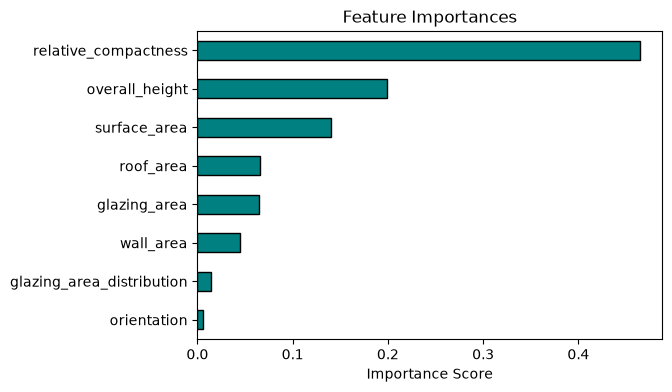

In [25]:
plt.figure(figsize=(6,4))
importances.plot(kind='barh',color='teal',edgecolor='black')
plt.xlabel('Importance Score')
plt.title('Feature Importances')
plt.gca().invert_yaxis()
plt.show()

**Observations**
- `relative_compactness` is the most important feature (about 46%), followed by `overall_height` (about 20%) and `surface_area` (about 14%). Together these three account for roughly 80% of the total importance.
- `orientation` (about 0.6%) and `glazing_area_distribution` (about 1.4%) contribute very little, which matches their near-zero correlation with the targets.
- Compactness, surface area and roof area are strongly related to one another, so importance is shared among them. The exact split between these features should be read with that in mind.

## 9. Predicted vs Actual

Points close to the red dashed line indicate accurate predictions. These plots use the random forest predictions on the test set.

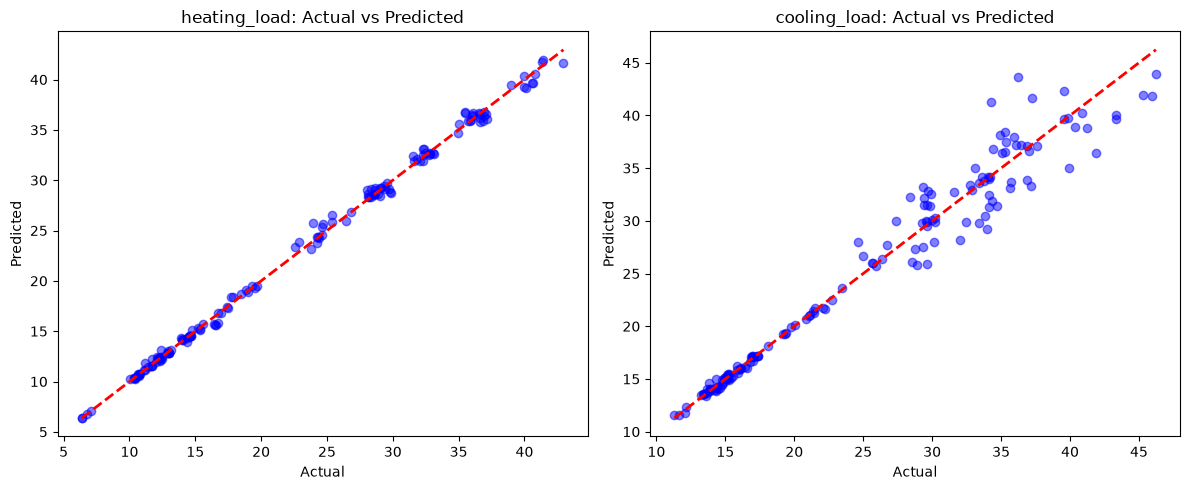

In [26]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, target in enumerate(y_test.columns):
    axes[i].scatter(y_test[target], y_pred[:, i], alpha=0.5, color='blue')
    axes[i].plot([y_test[target].min(), y_test[target].max()],
                 [y_test[target].min(), y_test[target].max()],
                 'r--', linewidth=2)
    axes[i].set_xlabel('Actual')
    axes[i].set_ylabel('Predicted')
    axes[i].set_title(f'{target}: Actual vs Predicted')

plt.tight_layout()
plt.show()

The heating load predictions sit very tightly on the diagonal. The cooling load predictions follow the diagonal too but with visibly more spread, which is consistent with the metrics above.

## 10. Key Findings

1. **Data quality was high.** There were no missing values or duplicates across 768 records, so the work focused on understanding and modeling rather than cleaning.
2. **Building shape drives energy demand.** Height, roof area, surface area and relative compactness show the strongest relationships with both loads.
3. **Orientation barely matters.** It has near-zero correlation with either target and the lowest importance in the random forest. Glazing distribution is also a weak signal, while glazing area has a modest positive effect.
4. **The relationship is not purely linear.** Linear regression already reaches R² of about 0.89 to 0.91, but the random forest lifts this to about 0.96 to 0.998.
5. **Heating load is easier to predict than cooling load.** The random forest reaches an R² of 0.998 for heating and 0.961 for cooling on unseen data.
6. **Three features carry most of the signal.** Relative compactness, overall height and surface area make up about 80% of the random forest's feature importance.
7. **Practical takeaway.** Compact, lower buildings with less surface area tend to need less heating and cooling, and early-stage design decisions on shape matter far more than orientation.

## 11. Limitations and Next Steps

**Limitations**
- The data is simulated and covers only a small number of distinct building shapes (768 rows built from a fixed design grid). Random train/test splitting means test rows can be very similar to training rows, so these scores are likely optimistic for genuinely new building designs.
- Random forest importances are shared among correlated features, so they show which features are useful, not a causal ranking.
- Random forest fits the training data almost perfectly, particularly for heating load, and the cooling load train/test gap shows mild overfitting.

**Possible next steps**
- Use cross-validation, and hold out entire building shapes (grouped splits) to test generalization to unseen designs.
- Tune random forest hyperparameters (depth, minimum leaf size, number of trees).
- Compare against gradient boosting models such as XGBoost or LightGBM.
- Try regularized linear models (Ridge, Lasso) to deal with the multicollinearity.
- Use permutation importance or SHAP for a more reliable view of feature effects.